# Lab 1 — Quá trình Poisson và Mô phỏng Hàng đợi M/M/1, M/M/n
**Môn:** NT531 — Đánh giá hiệu năng Mạng máy tính

| Thông tin | |
|---|---|
| **Họ và tên** | *(điền tên)* |
| **MSSV** | *(điền MSSV)* |

> **Ghi chú đối chiếu lý thuyết:** Các công thức trong notebook này đã được rà lại theo
> `lecture_02_arrival processes and queuing systems (1).pdf`.
> - Phần Poisson dùng đúng quan hệ: inter-arrival theo phân phối mũ và số arrival trong khoảng `T` theo phân phối Poisson (phần `Exponential Model` và `Poisson Model`, khoảng trang 11-15 của slide text).
> - Phần M/M/1 dùng đúng các công thức chuẩn `ρ = λ/μ`, `L = ρ/(1-ρ)`, `Lq = ρ²/(1-ρ)`, `W = 1/(μ-λ)`, `Wq = ρ/(μ-λ)`; đây là trường hợp riêng `n=1` của hệ Erlang delay `M/M/n` trong bài giảng.
> - Little's law trong notebook được áp dụng dưới dạng `L = λW`, `Lq = λWq`; điều này đúng cho phần M/M/1 của lab vì hệ không có loss nên throughput bằng đúng `λ`.


## Cài đặt và Import thư viện
Chạy cell bên dưới để cài đặt các thư viện cần thiết (nếu chưa có) và import.

In [1]:
# Cài đặt thư viện (bỏ comment nếu cần)
# !pip install numpy matplotlib scipy simpy

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import simpy

# Cấu hình đồ thị
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

# Đặt seed để kết quả tái lập được
np.random.seed(42)

---
# PHẦN 1: QUÁ TRÌNH ĐẾN POISSON
---

**Kịch bản:** Gói tin đến một bộ định tuyến mạng theo quá trình Poisson với tốc độ $\lambda = 2$ gói/giây.

Trong phần này, ta sẽ:
- Sinh thời gian giữa các lần đến (inter-arrival times) bằng phương pháp inverse transform
- Đếm số gói đến trong mỗi khe thời gian (time slot)
- So sánh phân phối thực nghiệm với phân phối Poisson lý thuyết

**Tham số:**
- $\lambda = 2$ gói/giây
- $N = 200$ gói tin
- Số khe thời gian: $40$
- Kích thước khe thời gian: $T_s = N / (\lambda \times \text{num\_slots}) = 2.5$ giây

In [2]:
# Tham số Phần 1
lam = 2          # Tốc độ đến (gói/giây)
N = 200          # Số gói tin
num_slots = 40   # Số khe thời gian
Ts = N / (lam * num_slots)  # Kích thước mỗi khe thời gian

print(f"λ = {lam} gói/giây")
print(f"N = {N} gói")
print(f"Số khe thời gian = {num_slots}")
print(f"Ts = {Ts:.4f} giây")
print(f"λ × Ts = {lam * Ts:.2f} (số gói trung bình mỗi khe)")

λ = 2 gói/giây
N = 200 gói
Số khe thời gian = 40
Ts = 2.5000 giây
λ × Ts = 5.00 (số gói trung bình mỗi khe)


In [3]:
# Sinh thời gian giữa các lần đến (inter-arrival times) bằng phương pháp inverse transform
# ---------------------------------------------------------------
# Với quá trình Poisson(λ), thời gian giữa các lần đến tuân theo
# phân phối mũ (Exponential) với CDF: F(t) = 1 - e^(-λt)
# Phương pháp inverse transform: t = -1/λ * ln(1 - U), U ~ Uniform(0,1)
# Kết quả: mảng N giá trị inter-arrival time
# ---------------------------------------------------------------
inter_arrival = (-1/lam) * np.log(1 - np.random.rand(N))

In [4]:
# Tính thời gian đến tích lũy (cumulative arrival times)
# ---------------------------------------------------------------
# arrival_times[i] = tổng các inter-arrival times từ 0 đến i
# Đây chính là thời điểm gói thứ i đến hệ thống
# np.cumsum thực hiện: [t1, t1+t2, t1+t2+t3, ...]
# ---------------------------------------------------------------
arrival_times = np.cumsum(inter_arrival)

# Kiểm tra: in 10 thời gian đến đầu tiên
print("10 thời gian đến đầu tiên:")
print(arrival_times[:10])

10 thời gian đến đầu tiên:
[0.23463404 1.73969476 2.39806761 2.85453888 2.93935132 3.02414947
 3.05406885 4.05968428 4.51922536 5.13485039]


In [5]:
# Đếm số gói đến trong mỗi khe thời gian
# ---------------------------------------------------------------
# Chia trục thời gian thành num_slots khe, mỗi khe dài Ts giây
# slot_edges = [0, Ts, 2*Ts, ..., num_slots*Ts]
# np.histogram đếm số arrival_times rơi vào mỗi khe
# counts[i] = số gói đến trong khe thời gian thứ i
# ---------------------------------------------------------------
slot_edges = np.arange(0, num_slots + 1) * Ts
counts, _ = np.histogram(arrival_times, bins=slot_edges)

print(f"Số gói đến mỗi khe (10 khe đầu): {counts[:10]}")

Số gói đến mỗi khe (10 khe đầu): [ 3  6  3 11  7  4  5  6  5  2]


In [6]:
# Tính PMF thực nghiệm — f(x) và %real
# ---------------------------------------------------------------
# PMF (Probability Mass Function): P(X = k) cho mỗi giá trị k
# empirical_pmf[k] = (số khe có đúng k gói đến) / (tổng số khe)
# Đây là tần suất thực nghiệm, tương ứng cột "%real" trong Excel
# k_values: từ 0 đến max(counts) — tất cả giá trị k có thể
# ---------------------------------------------------------------
max_k = int(counts.max())
k_values = np.arange(0, max_k + 1)
empirical_pmf = np.array([np.sum(counts == k) / num_slots for k in k_values])

print("k | f(k)  | %real")
print("-" * 25)
for k, p in zip(k_values, empirical_pmf):
    print(f"{k} | {p:.4f} | {p*100:.1f}%")

k | f(k)  | %real
-------------------------
0 | 0.0500 | 5.0%
1 | 0.0000 | 0.0%
2 | 0.0500 | 5.0%
3 | 0.1750 | 17.5%
4 | 0.1750 | 17.5%
5 | 0.2000 | 20.0%
6 | 0.1250 | 12.5%
7 | 0.0750 | 7.5%
8 | 0.0250 | 2.5%
9 | 0.0750 | 7.5%
10 | 0.0250 | 2.5%
11 | 0.0250 | 2.5%


In [7]:
# Tính PMF lý thuyết Poisson — %theory
# ---------------------------------------------------------------
# Công thức Poisson: P(X=k) = (λTs)^k * e^(-λTs) / k!
# Với λ=2, Ts=2.5 → λTs = 5.0 (trung bình 5 gói/khe)
# scipy.stats.poisson.pmf tính chính xác công thức trên
# Đây tương ứng cột "%theory" trong Excel
# ---------------------------------------------------------------
theoretical_pmf = stats.poisson.pmf(k_values, mu=lam * Ts)

print("k | %theory")
print("-" * 20)
for k, p in zip(k_values, theoretical_pmf):
    print(f"{k} | {p*100:.1f}%")

k | %theory
--------------------
0 | 0.7%
1 | 3.4%
2 | 8.4%
3 | 14.0%
4 | 17.5%
5 | 17.5%
6 | 14.6%
7 | 10.4%
8 | 6.5%
9 | 3.6%
10 | 1.8%
11 | 0.8%


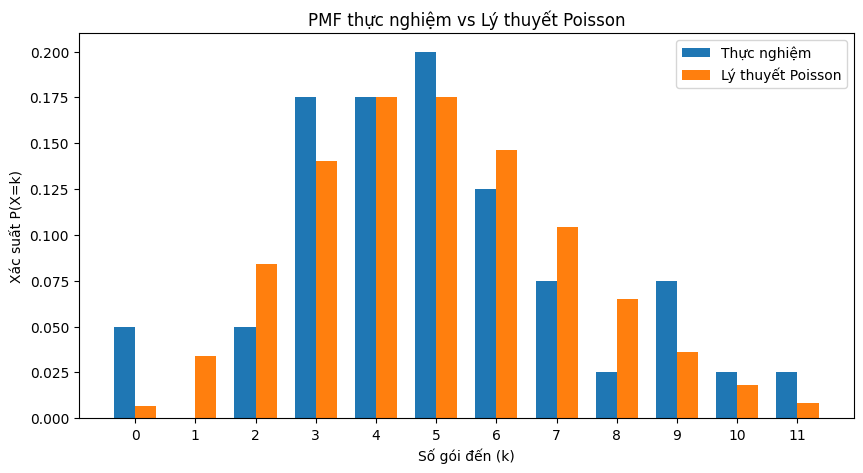

In [8]:
# Vẽ biểu đồ cột — PMF thực nghiệm vs lý thuyết
# ---------------------------------------------------------------
# Biểu đồ cột kép (grouped bar chart) so sánh:
# - Cột trái (xanh): tần suất thực nghiệm từ mô phỏng (%real)
# - Cột phải (cam): xác suất lý thuyết Poisson (%theory)
# Tương tự biểu đồ "Simulated vs Theoretical" trong Excel
# ---------------------------------------------------------------
width = 0.35
plt.bar(k_values - width/2, empirical_pmf, width, label='Thực nghiệm')
plt.bar(k_values + width/2, theoretical_pmf, width, label='Lý thuyết Poisson')
plt.xlabel('Số gói đến (k)')
plt.ylabel('Xác suất P(X=k)')
plt.title('PMF thực nghiệm vs Lý thuyết Poisson')
plt.xticks(k_values)
plt.legend()
plt.show()

In [9]:
# In trung bình và phương sai của số gói đến mỗi khe
# ---------------------------------------------------------------
# Tính chất quan trọng của phân phối Poisson:
#   Mean = Variance = λ × Ts
# Nếu mô phỏng đúng, mean và variance của counts phải xấp xỉ λ×Ts = 5.0
# Đây tương ứng các ô "Mean" và "Var" trong Excel
# ---------------------------------------------------------------
mean_counts = np.mean(counts)
var_counts = np.var(counts)

print(f"Trung bình (mean) số gói/khe:  {mean_counts:.4f}")
print(f"Phương sai (variance):          {var_counts:.4f}")
print(f"Giá trị lý thuyết (λ×Ts):      {lam * Ts:.4f}")
print(f"\nNhận xét: mean ≈ variance ≈ λ×Ts → đúng tính chất Poisson")

Trung bình (mean) số gói/khe:  5.0000
Phương sai (variance):          5.9500
Giá trị lý thuyết (λ×Ts):      5.0000

Nhận xét: mean ≈ variance ≈ λ×Ts → đúng tính chất Poisson


---
# PHẦN 2: MÔ PHỎNG HÀNG ĐỢI M/M/1 (PYTHON THUẦN)
---

## Ký hiệu Kendall: M/M/1
- **M** (Markovian): Thời gian đến tuân theo phân phối mũ → quá trình Poisson
- **M** (Markovian): Thời gian phục vụ tuân theo phân phối mũ
- **1**: 1 server (bộ phục vụ)

## Các công thức M/M/1

| Ký hiệu | Công thức | Ý nghĩa |
|:---:|:---:|:---|
| $\rho$ | $\lambda / \mu$ | Hệ số sử dụng (utilization), yêu cầu $\rho < 1$ |
| $L$ | $\rho / (1 - \rho)$ | Số trung bình trong hệ thống |
| $L_q$ | $\rho^2 / (1 - \rho)$ | Số trung bình trong hàng đợi |
| $W$ | $1 / (\mu - \lambda)$ | Thời gian trung bình trong hệ thống |
| $W_q$ | $\rho / (\mu - \lambda)$ | Thời gian chờ trung bình trong hàng đợi |

**Kịch bản:** $\lambda = 2$ gói/giây, $\mu = 3$ gói/giây, mô phỏng $N = 10.000$ gói.

In [10]:
# Tham số Phần 2
lam = 2           # Tốc độ đến (gói/giây)
mu = 3            # Tốc độ phục vụ (gói/giây)
num_packets = 10000  # Số gói tin mô phỏng

rho_theory = lam / mu
print(f"λ = {lam}, μ = {mu}")
print(f"ρ = λ/μ = {rho_theory:.4f}")
print(f"Hệ thống {'ổn định' if rho_theory < 1 else 'KHÔNG ổn định'}")
print(f"Số gói mô phỏng: {num_packets}")

λ = 2, μ = 3
ρ = λ/μ = 0.6667
Hệ thống ổn định
Số gói mô phỏng: 10000


In [11]:
# Sinh thời gian giữa các lần đến (exponential, rate λ)
# ---------------------------------------------------------------
# Với quá trình Poisson(λ=2), inter-arrival ~ Exp(1/λ)
# np.random.exponential(scale=1/λ) sinh N mẫu từ phân phối mũ
# Mean inter-arrival = 1/λ = 0.5 giây
# ---------------------------------------------------------------
inter_arrival = np.random.exponential(1/lam, num_packets)

In [12]:
# Sinh thời gian phục vụ (exponential, rate μ)
# ---------------------------------------------------------------
# Thời gian phục vụ tuân theo phân phối mũ Exp(1/μ)
# Mean service time = 1/μ = 1/3 ≈ 0.333 giây
# Đây là đặc trưng "M" thứ hai trong ký hiệu M/M/1
# ---------------------------------------------------------------
service_time = np.random.exponential(1/mu, num_packets)

In [13]:
# Vòng lặp mô phỏng M/M/1 (event-driven)
# ---------------------------------------------------------------
# Mô phỏng từng gói tin qua hệ thống FIFO 1 server:
#   arrival_time[i]   = thời điểm gói i đến (tích lũy inter-arrival)
#   service_start[i]  = max(arrival_time[i], departure_time[i-1])
#                        → gói phải chờ nếu server chưa rảnh
#   departure_time[i] = service_start[i] + service_time[i]
#   wait_time[i]      = service_start[i] - arrival_time[i]
#                        → thời gian chờ trong hàng đợi (Wq)
# ---------------------------------------------------------------
arrival_time = np.zeros(num_packets)
service_start = np.zeros(num_packets)
departure_time = np.zeros(num_packets)
wait_time = np.zeros(num_packets)

# Gói đầu tiên (i=0): không phải chờ, được phục vụ ngay
arrival_time[0] = inter_arrival[0]
service_start[0] = arrival_time[0]
departure_time[0] = service_start[0] + service_time[0]
wait_time[0] = 0

for i in range(1, num_packets):
    arrival_time[i] = arrival_time[i-1] + inter_arrival[i]
    service_start[i] = max(arrival_time[i], departure_time[i-1])
    departure_time[i] = service_start[i] + service_time[i]
    wait_time[i] = service_start[i] - arrival_time[i]

print("Mô phỏng hoàn tất!")
print(f"Thời gian mô phỏng: {departure_time[-1]:.2f} giây")

Mô phỏng hoàn tất!
Thời gian mô phỏng: 4890.22 giây


In [14]:
# Tính các chỉ số mô phỏng
# ---------------------------------------------------------------
# W  = mean(departure - arrival)     → thời gian trung bình trong hệ thống
# Wq = mean(wait_time)               → thời gian chờ trung bình trong hàng đợi
# L  = W × λ    (Little's formula)   → số gói trung bình trong hệ thống
# Lq = Wq × λ   (Little's formula)   → số gói trung bình trong hàng đợi
# ρ  = tổng service_time / tổng thời gian → hệ số sử dụng server
# ---------------------------------------------------------------
W_sim = np.mean(departure_time - arrival_time)
Wq_sim = np.mean(wait_time)
L_sim = W_sim * lam
Lq_sim = Wq_sim * lam
rho_sim = np.sum(service_time) / departure_time[-1]

print("=== Kết quả mô phỏng ===")
print(f"ρ (sim)  = {rho_sim:.4f}")
print(f"L (sim)  = {L_sim:.4f}")
print(f"Lq (sim) = {Lq_sim:.4f}")
print(f"W (sim)  = {W_sim:.4f} giây")
print(f"Wq (sim) = {Wq_sim:.4f} giây")

=== Kết quả mô phỏng ===
ρ (sim)  = 0.6937
L (sim)  = 2.2120
Lq (sim) = 1.5335
W (sim)  = 1.1060 giây
Wq (sim) = 0.7667 giây


In [15]:
# Tính các chỉ số lý thuyết M/M/1
# ---------------------------------------------------------------
# Công thức closed-form cho hệ thống M/M/1:
#   ρ  = λ/μ                    (hệ số sử dụng, cần ρ < 1)
#   L  = ρ/(1-ρ)                (số trung bình trong hệ thống)
#   Lq = ρ²/(1-ρ)               (số trung bình trong hàng đợi)
#   W  = 1/(μ-λ)                (thời gian trung bình trong hệ thống)
#   Wq = ρ/(μ-λ)                (thời gian chờ trung bình)
# ---------------------------------------------------------------
rho_th = lam / mu
L_th = rho_th / (1 - rho_th)
Lq_th = rho_th**2 / (1 - rho_th)
W_th = 1 / (mu - lam)
Wq_th = rho_th / (mu - lam)

print("=== Kết quả lý thuyết M/M/1 ===")
print(f"ρ  = {rho_th:.4f}")
print(f"L  = {L_th:.4f}")
print(f"Lq = {Lq_th:.4f}")
print(f"W  = {W_th:.4f} giây")
print(f"Wq = {Wq_th:.4f} giây")

=== Kết quả lý thuyết M/M/1 ===
ρ  = 0.6667
L  = 2.0000
Lq = 1.3333
W  = 1.0000 giây
Wq = 0.6667 giây


In [16]:
# In bảng so sánh — mô phỏng vs lý thuyết
# ---------------------------------------------------------------
# So sánh kết quả mô phỏng với giá trị lý thuyết closed-form
# Sai số (%) = |sim - theory| / theory × 100
# Kỳ vọng sai số trong khoảng 5-10% với N=10000 gói
# ---------------------------------------------------------------
metrics = [
    ("ρ",  rho_sim, rho_th),
    ("L",  L_sim,   L_th),
    ("Lq", Lq_sim,  Lq_th),
    ("W",  W_sim,   W_th),
    ("Wq", Wq_sim,  Wq_th),
]

print(f"{'Chỉ số':<8} {'Mô phỏng':>12} {'Lý thuyết':>12} {'Sai số (%)':>12}")
print("-" * 48)
for name, sim, th in metrics:
    err = abs(sim - th) / th * 100
    print(f"{name:<8} {sim:>12.4f} {th:>12.4f} {err:>11.2f}%")

Chỉ số       Mô phỏng    Lý thuyết   Sai số (%)
------------------------------------------------
ρ              0.6937       0.6667        4.06%
L              2.2120       2.0000       10.60%
Lq             1.5335       1.3333       15.01%
W              1.1060       1.0000       10.60%
Wq             0.7667       0.6667       15.01%


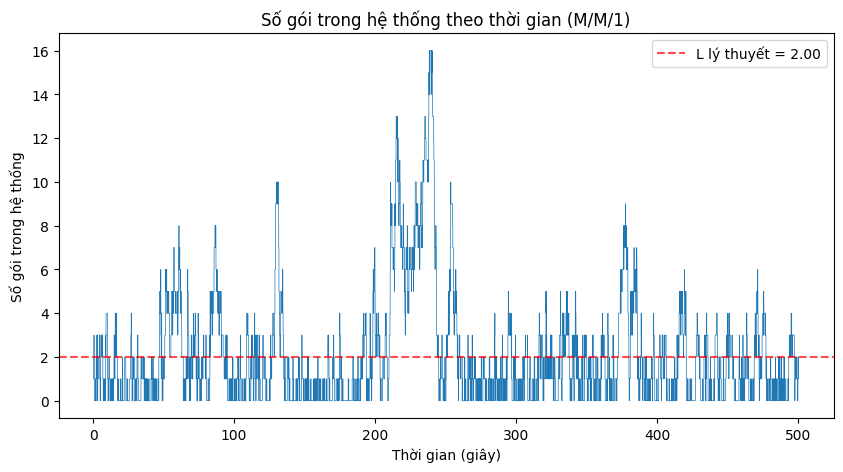

In [17]:
# Vẽ biểu đồ — Số gói trong hệ thống theo thời gian
# ---------------------------------------------------------------
# Tạo chuỗi sự kiện: mỗi arrival → +1, mỗi departure → -1
# Sắp xếp theo thời gian rồi cumsum → số gói trong hệ thống tại mỗi thời điểm
# Đường ngang đỏ: giá trị lý thuyết L = ρ/(1-ρ)
# Chỉ vẽ 500 giây đầu để dễ quan sát dao động
# ---------------------------------------------------------------
event_times = np.concatenate([arrival_time, departure_time])
event_types = np.concatenate([np.ones(num_packets), -np.ones(num_packets)])
order = np.argsort(event_times)
event_times = event_times[order]
event_types = event_types[order]
num_in_system = np.cumsum(event_types)

mask = event_times <= 500
plt.step(event_times[mask], num_in_system[mask], where='post', linewidth=0.5)
plt.xlabel('Thời gian (giây)')
plt.ylabel('Số gói trong hệ thống')
plt.title('Số gói trong hệ thống theo thời gian (M/M/1)')
plt.axhline(y=L_th, color='r', linestyle='--', alpha=0.7, label=f'L lý thuyết = {L_th:.2f}')
plt.legend()
plt.show()

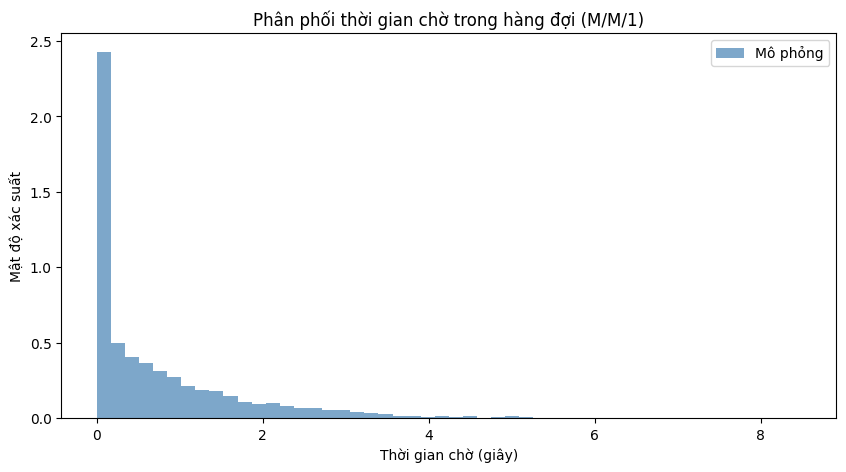

In [18]:
# Vẽ histogram thời gian chờ
# ---------------------------------------------------------------
# Phân phối thời gian chờ Wq trong hàng đợi M/M/1
# Histogram chuẩn hóa (density=True) → xấp xỉ mật độ xác suất
# Nhiều gói có wait_time = 0 (server rảnh khi gói đến)
# ---------------------------------------------------------------
plt.hist(wait_time, bins=50, density=True, alpha=0.7, label='Mô phỏng', color='steelblue')
plt.xlabel('Thời gian chờ (giây)')
plt.ylabel('Mật độ xác suất')
plt.title('Phân phối thời gian chờ trong hàng đợi (M/M/1)')
plt.legend()
plt.show()

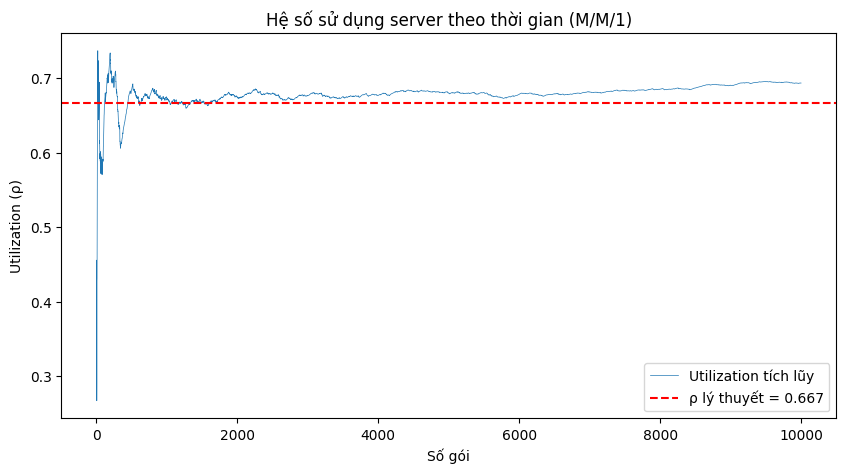

In [19]:
# Vẽ hệ số sử dụng server theo thời gian (tích lũy)
# ---------------------------------------------------------------
# utilization[i] = tổng service_time[0:i] / departure_time[i]
# Theo thời gian, utilization hội tụ về ρ = λ/μ (lý thuyết)
# Đường ngang đỏ: giá trị ρ lý thuyết
# ---------------------------------------------------------------
busy_cumsum = np.cumsum(service_time)
utilization = busy_cumsum / departure_time

plt.plot(np.arange(1, num_packets+1), utilization, linewidth=0.5, label='Utilization tích lũy')
plt.axhline(y=rho_th, color='r', linestyle='--', label=f'ρ lý thuyết = {rho_th:.3f}')
plt.xlabel('Số gói')
plt.ylabel('Utilization (ρ)')
plt.title('Hệ số sử dụng server theo thời gian (M/M/1)')
plt.legend()
plt.show()

---
# PHẦN 3: MÔ PHỎNG BẰNG SIMPY + M/M/n
---

## SimPy là gì?
[SimPy](https://simpy.readthedocs.io/) là thư viện mô phỏng sự kiện rời rạc (discrete-event simulation) cho Python.

Các khái niệm chính:
- **Environment**: Quản lý thời gian mô phỏng
- **Process**: Các tiến trình (ví dụ: gói tin đến, xử lý)
- **Resource**: Tài nguyên có giới hạn (ví dụ: server)

Với `simpy.Resource(env, capacity=n)`, ta dễ dàng mô phỏng hệ thống M/M/n.

In [20]:
# Mô phỏng M/M/1 bằng SimPy
# ---------------------------------------------------------------
# SimPy sử dụng mô hình discrete-event simulation:
#   - packet_generator: sinh gói tin theo Poisson (inter-arrival ~ Exp(1/λ))
#   - packet: mỗi gói yêu cầu server (Resource), chờ nếu bận,
#             rồi được phục vụ trong thời gian ~ Exp(1/μ)
#   - simpy.Resource(capacity=n): mô phỏng n server song song
# Hàm simpy_mm1 trả về danh sách thời gian chờ của tất cả gói
# ---------------------------------------------------------------

def simpy_mm1(lam, mu, num_packets, num_servers=1):
    """Mô phỏng M/M/n bằng SimPy. Trả về danh sách thời gian chờ."""
    wait_times = []
    
    def packet(env, server, mu):
        """Process: một gói tin đến, chờ server, được xử lý."""
        arrive = env.now
        with server.request() as req:
            yield req
            wait = env.now - arrive
            wait_times.append(wait)
            yield env.timeout(np.random.exponential(1/mu))
    
    def packet_generator(env, server, lam, mu, num_packets):
        """Process: sinh gói tin theo quá trình Poisson."""
        for i in range(num_packets):
            yield env.timeout(np.random.exponential(1/lam))
            env.process(packet(env, server, mu))
    
    # Tạo môi trường SimPy và chạy
    env = simpy.Environment()
    server = simpy.Resource(env, capacity=num_servers)
    env.process(packet_generator(env, server, lam, mu, num_packets))
    env.run()
    
    return wait_times

# Chạy M/M/1 bằng SimPy với cùng tham số λ=2, μ=3
np.random.seed(42)
wait_times_simpy = simpy_mm1(lam=2, mu=3, num_packets=10000, num_servers=1)

Wq_simpy = np.mean(wait_times_simpy)
W_simpy = Wq_simpy + 1/mu
L_simpy = lam * W_simpy
Lq_simpy = lam * Wq_simpy

print("=== Kết quả SimPy M/M/1 ===")
print(f"Wq (SimPy) = {Wq_simpy:.4f} giây")
print(f"W  (SimPy) = {W_simpy:.4f} giây")
print(f"Lq (SimPy) = {Lq_simpy:.4f}")
print(f"L  (SimPy) = {L_simpy:.4f}")

=== Kết quả SimPy M/M/1 ===
Wq (SimPy) = 0.6866 giây
W  (SimPy) = 1.0199 giây
Lq (SimPy) = 1.3732
L  (SimPy) = 2.0399


In [21]:
# So sánh SimPy M/M/1 vs Python thuần (Phần 2)
# ---------------------------------------------------------------
# Cả hai phương pháp mô phỏng cùng hệ thống M/M/1 (λ=2, μ=3)
# Kết quả phải xấp xỉ nhau và gần giá trị lý thuyết
# Sự khác biệt nhỏ do random seed khác nhau giữa hai lần chạy
# ---------------------------------------------------------------
print(f"{'Chỉ số':<8} {'Python thuần':>14} {'SimPy':>14} {'Lý thuyết':>14}")
print("-" * 56)
for name, py_val, sp_val, th_val in [
    ("W",  W_sim,  W_simpy,  W_th),
    ("Wq", Wq_sim, Wq_simpy, Wq_th),
    ("L",  L_sim,  L_simpy,  L_th),
    ("Lq", Lq_sim, Lq_simpy, Lq_th),
]:
    print(f"{name:<8} {py_val:>14.4f} {sp_val:>14.4f} {th_val:>14.4f}")

Chỉ số     Python thuần          SimPy      Lý thuyết
--------------------------------------------------------
W                1.1060         1.0199         1.0000
Wq               0.7667         0.6866         0.6667
L                2.2120         2.0399         2.0000
Lq               1.5335         1.3732         1.3333


In [22]:
# Mở rộng sang M/M/n — hệ thống nhiều server
# ---------------------------------------------------------------
# M/M/n: cùng quá trình đến Poisson(λ), nhưng có n server song song
# Mỗi server phục vụ độc lập với tốc độ μ
# ρ per server = λ / (n × μ), yêu cầu ρ < 1 để hệ thống ổn định
# Với λ=2, μ=1: cần ít nhất n=3 server (n=2 → ρ=1.0, không ổn định)
# Chạy mô phỏng SimPy cho từng giá trị n và so sánh Wq
# ---------------------------------------------------------------
lam_mmn = 2
mu_mmn = 1
servers_list = [3, 4, 5, 6]

Wq_results = {}

for n in servers_list:
    rho_n = lam_mmn / (n * mu_mmn)
    if rho_n >= 1:
        print(f"n={n}: ρ = {rho_n:.3f} >= 1 → hệ thống không ổn định, bỏ qua.")
        continue
    np.random.seed(42)
    wt = simpy_mm1(lam_mmn, mu_mmn, 10000, num_servers=n)
    Wq_results[n] = np.mean(wt)

print("\n=== Kết quả M/M/n ===")
print(f"{'n':>4} {'ρ per server':>14} {'Wq (giây)':>14}")
print("-" * 36)
for n, wq in sorted(Wq_results.items()):
    rho_n = lam_mmn / (n * mu_mmn)
    print(f"{n:>4} {rho_n:>14.4f} {wq:>14.4f}")


=== Kết quả M/M/n ===
   n   ρ per server      Wq (giây)
------------------------------------
   3         0.6667         0.5525
   4         0.5000         0.0908
   5         0.4000         0.0172
   6         0.3333         0.0041


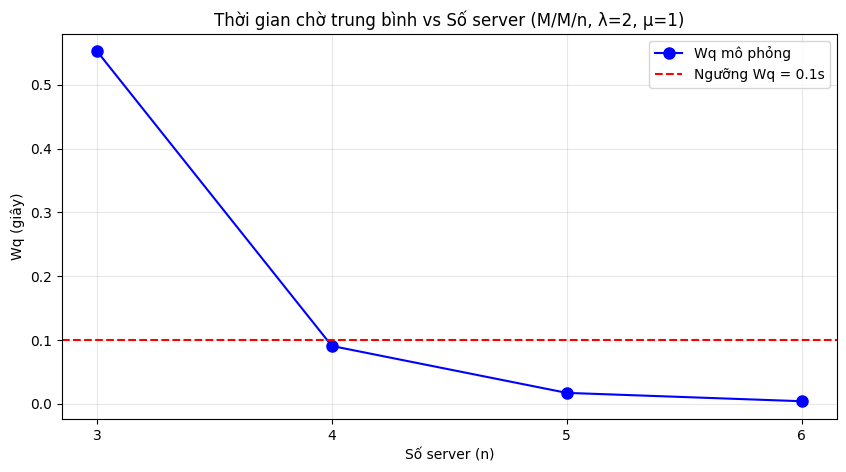

In [23]:
# Vẽ biểu đồ — Wq vs số server n
# ---------------------------------------------------------------
# Biểu đồ thể hiện thời gian chờ Wq giảm khi tăng số server
# Đường ngang đỏ: ngưỡng Wq = 0.1 giây (yêu cầu QoS)
# Từ biểu đồ → xác định số server tối thiểu để Wq < 0.1s
# ---------------------------------------------------------------
plt.plot(list(Wq_results.keys()), list(Wq_results.values()), 'bo-', markersize=8, label='Wq mô phỏng')
plt.axhline(y=0.1, color='r', linestyle='--', label='Ngưỡng Wq = 0.1s')
plt.xlabel('Số server (n)')
plt.ylabel('Wq (giây)')
plt.title('Thời gian chờ trung bình vs Số server (M/M/n, λ=2, μ=1)')
plt.xticks(list(Wq_results.keys()))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---
## Câu hỏi thảo luận

Trả lời các câu hỏi sau trong báo cáo:

**Q1:** Khi $\rho \to 1$, điều gì xảy ra với thời gian chờ $W_q$? Giải thích bằng công thức và bằng kết quả mô phỏng.

**Q2:** So sánh kết quả mô phỏng M/M/1 giữa Python thuần (Phần 2) và SimPy (Phần 3). Có khác biệt đáng kể không? Giải thích tại sao.

**Q3:** Với M/M/n, cho $\lambda = 2$ gói/giây và $\mu = 1$ gói/giây, cần bao nhiêu server để $W_q < 0{.}1$ giây? Trả lời bằng cách chạy mô phỏng với các giá trị $n$ khác nhau.

---
*Hết bài lab 1.*